# Machine Learning Course - CNNs, RNNs, and LSTMs

In [1]:
# ── Core numerical and plotting libraries ──────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── TensorFlow / Keras: the main deep-learning framework we use throughout ─────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist, cifar10   # built-in benchmark datasets
from tensorflow.keras.utils import to_categorical      # converts integer labels to one-hot vectors

# ── scikit-learn utilities for evaluation and preprocessing ────────────────────
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler         # scales data to [0, 1]

# Fix random seeds so results are reproducible across runs
np.random.seed(42)
tf.random.set_seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1775437292.403337  144772 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775437292.403628  144772 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775437292.428548  144772 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Libraries imported successfully!
NumPy version: 2.4.4
TensorFlow version: 2.21.0


I0000 00:00:1775437293.184558  144772 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775437293.184738  144772 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


---
## 10. Convolutional Neural Networks

A convolutional layer applies learnable filters over the input. For a 2D input $f$ and filter $\psi$, the output feature map is:

$$z[i, j] = (f * \psi)[i, j] = \sum_m \sum_n f[i+m,\, j+n] \cdot \psi[m, n]$$

A max-pooling layer reduces spatial dimensions by retaining the maximum value over a local window of size $p$ with stride $s$:

$$P[i,j] = \max_{m,n \in [0,p-1]^2} z[i \cdot s + m,\, j \cdot s + n]$$

A typical CNN stacks convolution + activation + pooling blocks, then flattens and applies dense layers for classification.

### CNN on MNIST

In [2]:
# MNIST: 60 000 training images, 10 000 test images of handwritten digits (0-9)
# Each image is 28×28 pixels in greyscale.
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

# np.newaxis adds a channel dimension: (N, 28, 28) → (N, 28, 28, 1)
# CNNs expect (batch, height, width, channels) as input.
# We also normalise pixel values from [0, 255] to [0.0, 1.0] for stable training.
X_train_mnist = X_train_mnist[..., np.newaxis].astype('float32') / 255.0
X_test_mnist  = X_test_mnist[..., np.newaxis].astype('float32') / 255.0

# to_categorical converts integer labels (e.g. 3) to one-hot vectors (e.g. [0,0,0,1,0,...])
# Required because we use categorical_crossentropy as our loss function.
y_train_cat   = to_categorical(y_train_mnist, 10)
y_test_cat    = to_categorical(y_test_mnist, 10)

print(f"Train: {X_train_mnist.shape}, Test: {X_test_mnist.shape}")

Train: (60000, 28, 28, 1), Test: (10000, 28, 28, 1)


In [3]:
# ── Build a CNN for MNIST ──────────────────────────────────────────────────────
# Architecture: two Conv+Pool blocks to extract spatial features, then Dense layers
# for classification.
#
# Conv2D(32, (3,3)):   32 filters of size 3×3 learn local edge/texture patterns (ψ in the formula)
# MaxPooling2D(2,2):   halves the spatial dimensions, keeping the strongest activations
# Flatten:             converts the 2-D feature maps into a 1-D vector for the Dense layers
# Dense(128, relu):    fully connected hidden layer
# Dense(10, softmax):  output layer — one probability per digit class
cnn_mnist = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),   # 64 filters: deeper features
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Adam: adaptive learning-rate optimiser (generally a safe default)
# categorical_crossentropy: standard multi-class classification loss
cnn_mnist.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_mnist.summary()

/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1775437293.582350  144772 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775437293.582644  144845 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775437293.604940  144772 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Train for 8 epochs.  validation_split=0.1 reserves 10% of training data
# for validation — lets us monitor overfitting during training without touching
# the test set.  batch_size=128 means weights are updated every 128 images.
history_cnn_mnist = cnn_mnist.fit(
    X_train_mnist, y_train_cat,
    validation_split=0.1,
    epochs=8,
    batch_size=128,
    verbose=1
)

# Final evaluation on the held-out test set (never seen during training)
test_loss, test_acc = cnn_mnist.evaluate(X_test_mnist, y_test_cat, verbose=0)
print(f"\nTest Accuracy: {test_acc:.2%}")

Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9353 - loss: 0.2179 - val_accuracy: 0.9827 - val_loss: 0.0613
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9820 - loss: 0.0589 - val_accuracy: 0.9877 - val_loss: 0.0447
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9878 - loss: 0.0397 - val_accuracy: 0.9888 - val_loss: 0.0380
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9909 - loss: 0.0300 - val_accuracy: 0.9895 - val_loss: 0.0362
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9931 - loss: 0.0234 - val_accuracy: 0.9905 - val_loss: 0.0371
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9944 - loss: 0.0186 - val_accuracy: 0.9885 - val_loss: 0.0430
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9956 - loss: 0.0148 - val_accuracy: 0.9895 - val_loss: 0.0429
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9964 - loss: 0.0124 - val_accuracy: 0.

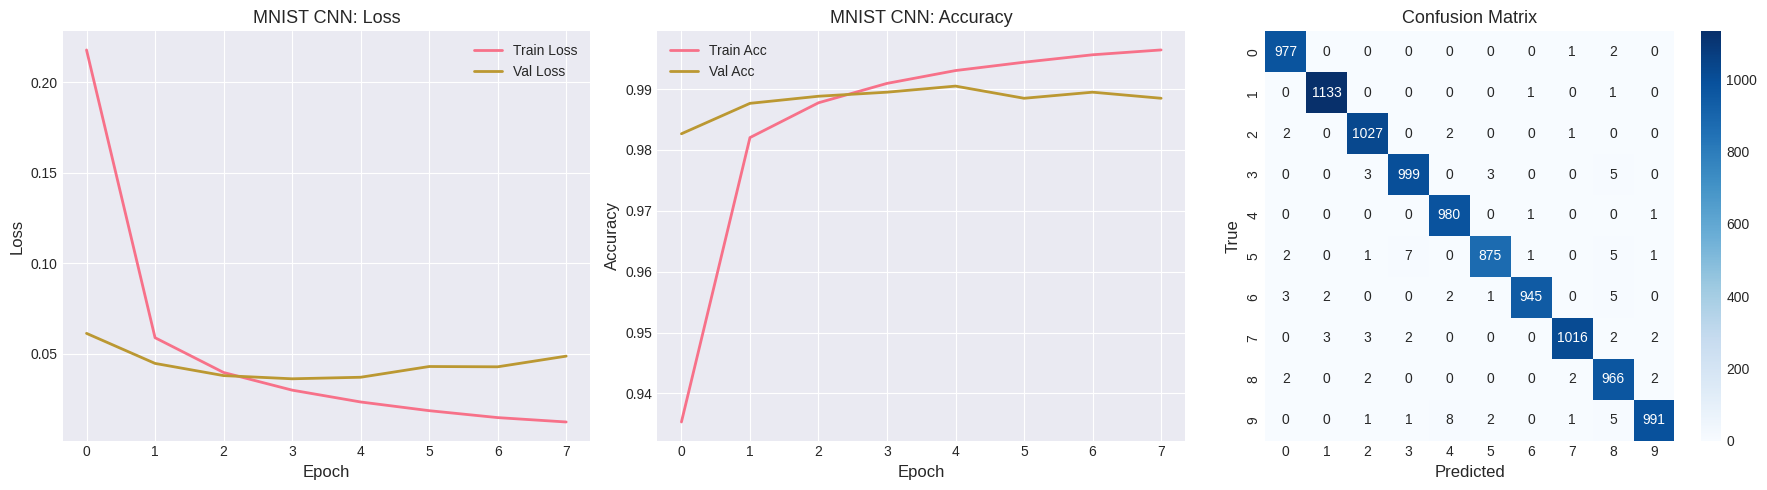

In [5]:
# ── Visualise training history and predictions ─────────────────────────────────
# Loss curves: if val_loss diverges upward from train_loss → overfitting.
# Accuracy curves: both should rise and converge.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_cnn_mnist.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_cnn_mnist.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('MNIST CNN: Loss', fontsize=13)
axes[0].legend()

axes[1].plot(history_cnn_mnist.history['accuracy'], label='Train Acc', linewidth=2)
axes[1].plot(history_cnn_mnist.history['val_accuracy'], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('MNIST CNN: Accuracy', fontsize=13)
axes[1].legend()

# Confusion matrix: rows = true class, columns = predicted class.
# Diagonal entries are correct predictions; off-diagonal entries are errors.
# np.argmax converts softmax probabilities back to integer class labels.
y_pred_mnist = np.argmax(cnn_mnist.predict(X_test_mnist, verbose=0), axis=1)
cm = confusion_matrix(y_test_mnist, y_pred_mnist)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2], square=True)
axes[2].set_xlabel('Predicted', fontsize=12)
axes[2].set_ylabel('True', fontsize=12)
axes[2].set_title('Confusion Matrix', fontsize=13)

plt.tight_layout()
plt.show()

### CNN on CIFAR-10

/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)


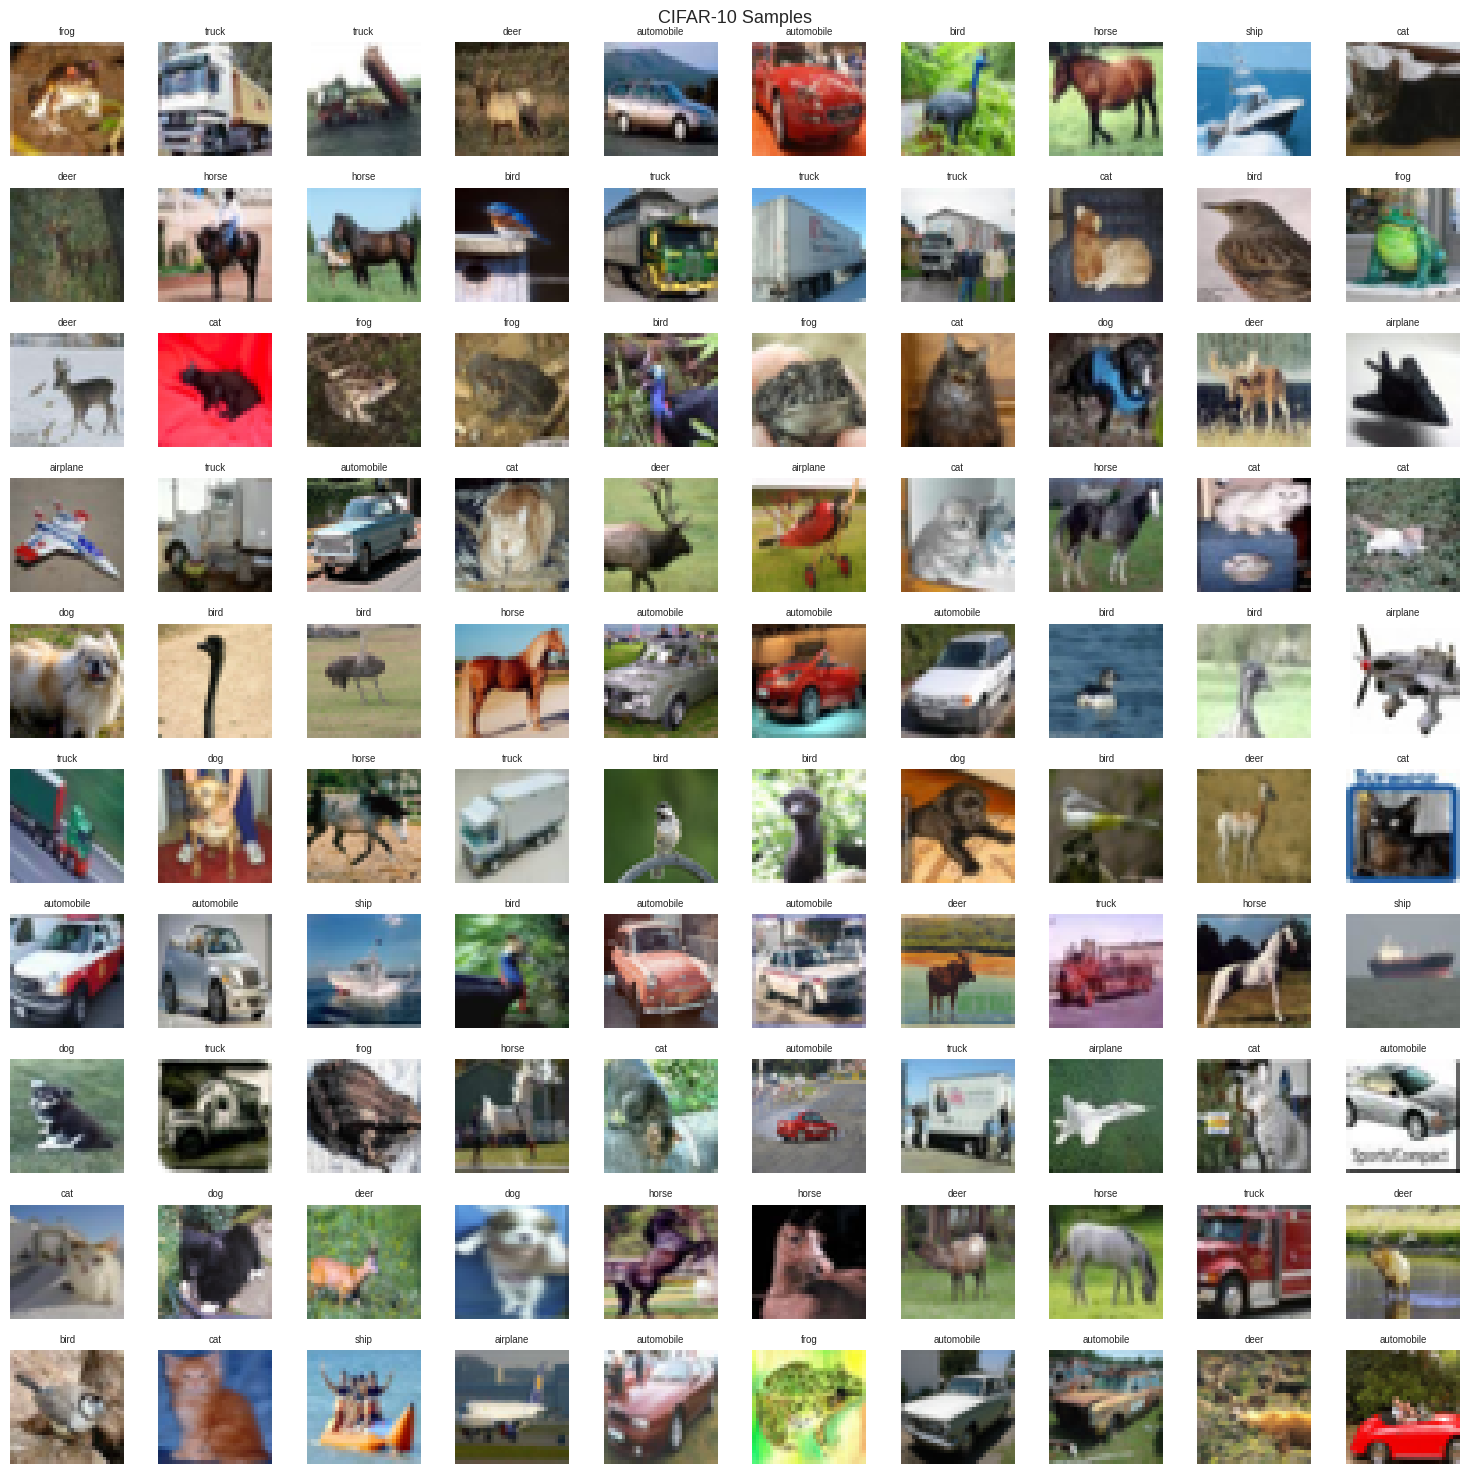

In [6]:
# CIFAR-10: 60 000 colour images (32×32 RGB) across 10 object categories.
# Harder than MNIST because of colour, background clutter, and inter-class similarity.
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()

# Normalise to [0, 1]; labels come as shape (N, 1) from cifar10.load_data()
X_train_cifar = X_train_cifar.astype('float32') / 255.0
X_test_cifar  = X_test_cifar.astype('float32') / 255.0
y_train_cifar_cat = to_categorical(y_train_cifar, 10)
y_test_cifar_cat  = to_categorical(y_test_cifar, 10)

cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Train: {X_train_cifar.shape}, Test: {X_test_cifar.shape}")

# Display the first 100 training images in a 10×10 grid to get a feel for the data
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train_cifar[i])
    # y_train_cifar[i, 0]: index into the 1-element label array returned by cifar10
    ax.set_title(cifar_classes[int(y_train_cifar[i, 0])], fontsize=7)
    ax.axis('off')
plt.suptitle('CIFAR-10 Samples', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# ── Deeper CNN for CIFAR-10 ────────────────────────────────────────────────────
# CIFAR-10 is more complex than MNIST, so we use a deeper architecture:
#   • Two convolutional blocks, each with two Conv2D layers before pooling.
#     Stacking convolutions before pooling lets the network build richer features.
#   • padding='same' keeps the spatial size constant after convolution.
#   • Dropout: randomly zeros a fraction of neurons during training to reduce
#     overfitting (acts as regularisation, not present in the MNIST model above).
#   • Larger Dense(512) head because we have 3-channel 32×32 input (more complex).
cnn_cifar = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),          # drop 25% of activations after first pooling
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),           # stronger dropout before the output layer
    layers.Dense(10, activation='softmax')
])

cnn_cifar.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_cifar.summary()

/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250,858 (4.77 MB)

 Trainable params: 1,250,858 (4.77 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train for 20 epochs — CIFAR-10 needs more passes than MNIST because the task
# is harder and the network is deeper.  batch_size=64 (smaller than MNIST's 128)
# gives more gradient updates per epoch, which can help on a noisier dataset.
history_cnn_cifar = cnn_cifar.fit(
    X_train_cifar, y_train_cifar_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    verbose=1
)

test_loss_cifar, test_acc_cifar = cnn_cifar.evaluate(X_test_cifar, y_test_cifar_cat, verbose=0)
print(f"\nTest Accuracy: {test_acc_cifar:.2%}")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.4282 - loss: 1.5620 - val_accuracy: 0.5248 - val_loss: 1.3217
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.5812 - loss: 1.1818 - val_accuracy: 0.6468 - val_loss: 1.0141
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.6374 - loss: 1.0238 - val_accuracy: 0.6954 - val_loss: 0.8750
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.6786 - loss: 0.9146 - val_accuracy: 0.7178 - val_loss: 0.8145
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.7062 - loss: 0.8361 - val_accuracy: 0.7294 - val_loss: 0.7714
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7282 - loss: 0.7754 - val_accuracy: 0.7502 - val_loss: 0.7335
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7440 - loss: 0.7258 - val_accuracy: 0.7518 - val_loss: 0.7085
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.7588 - loss: 0.6846 - 

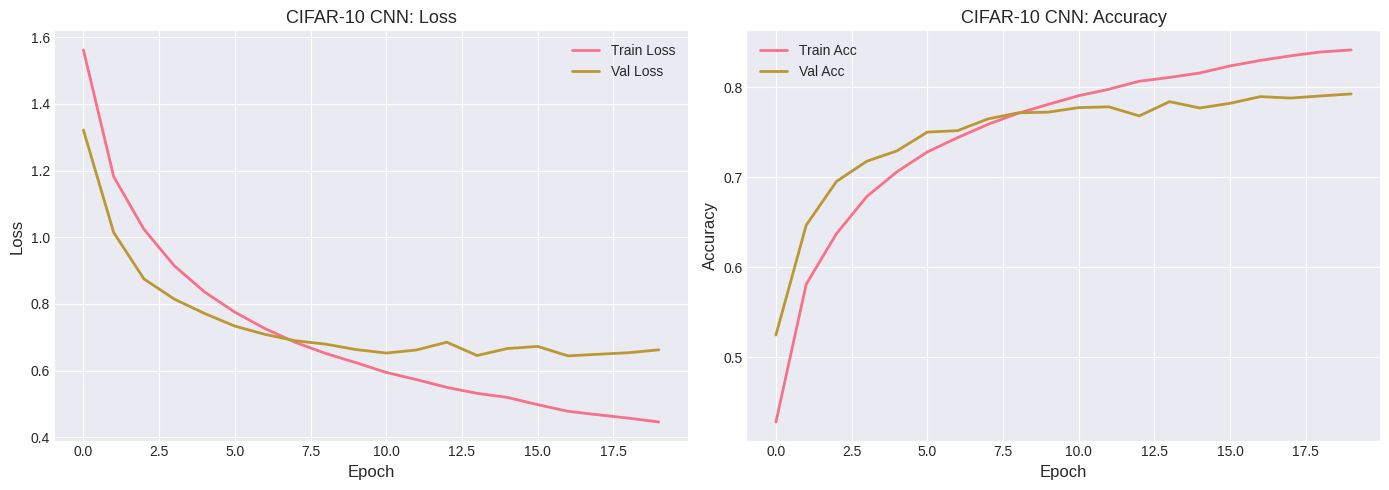

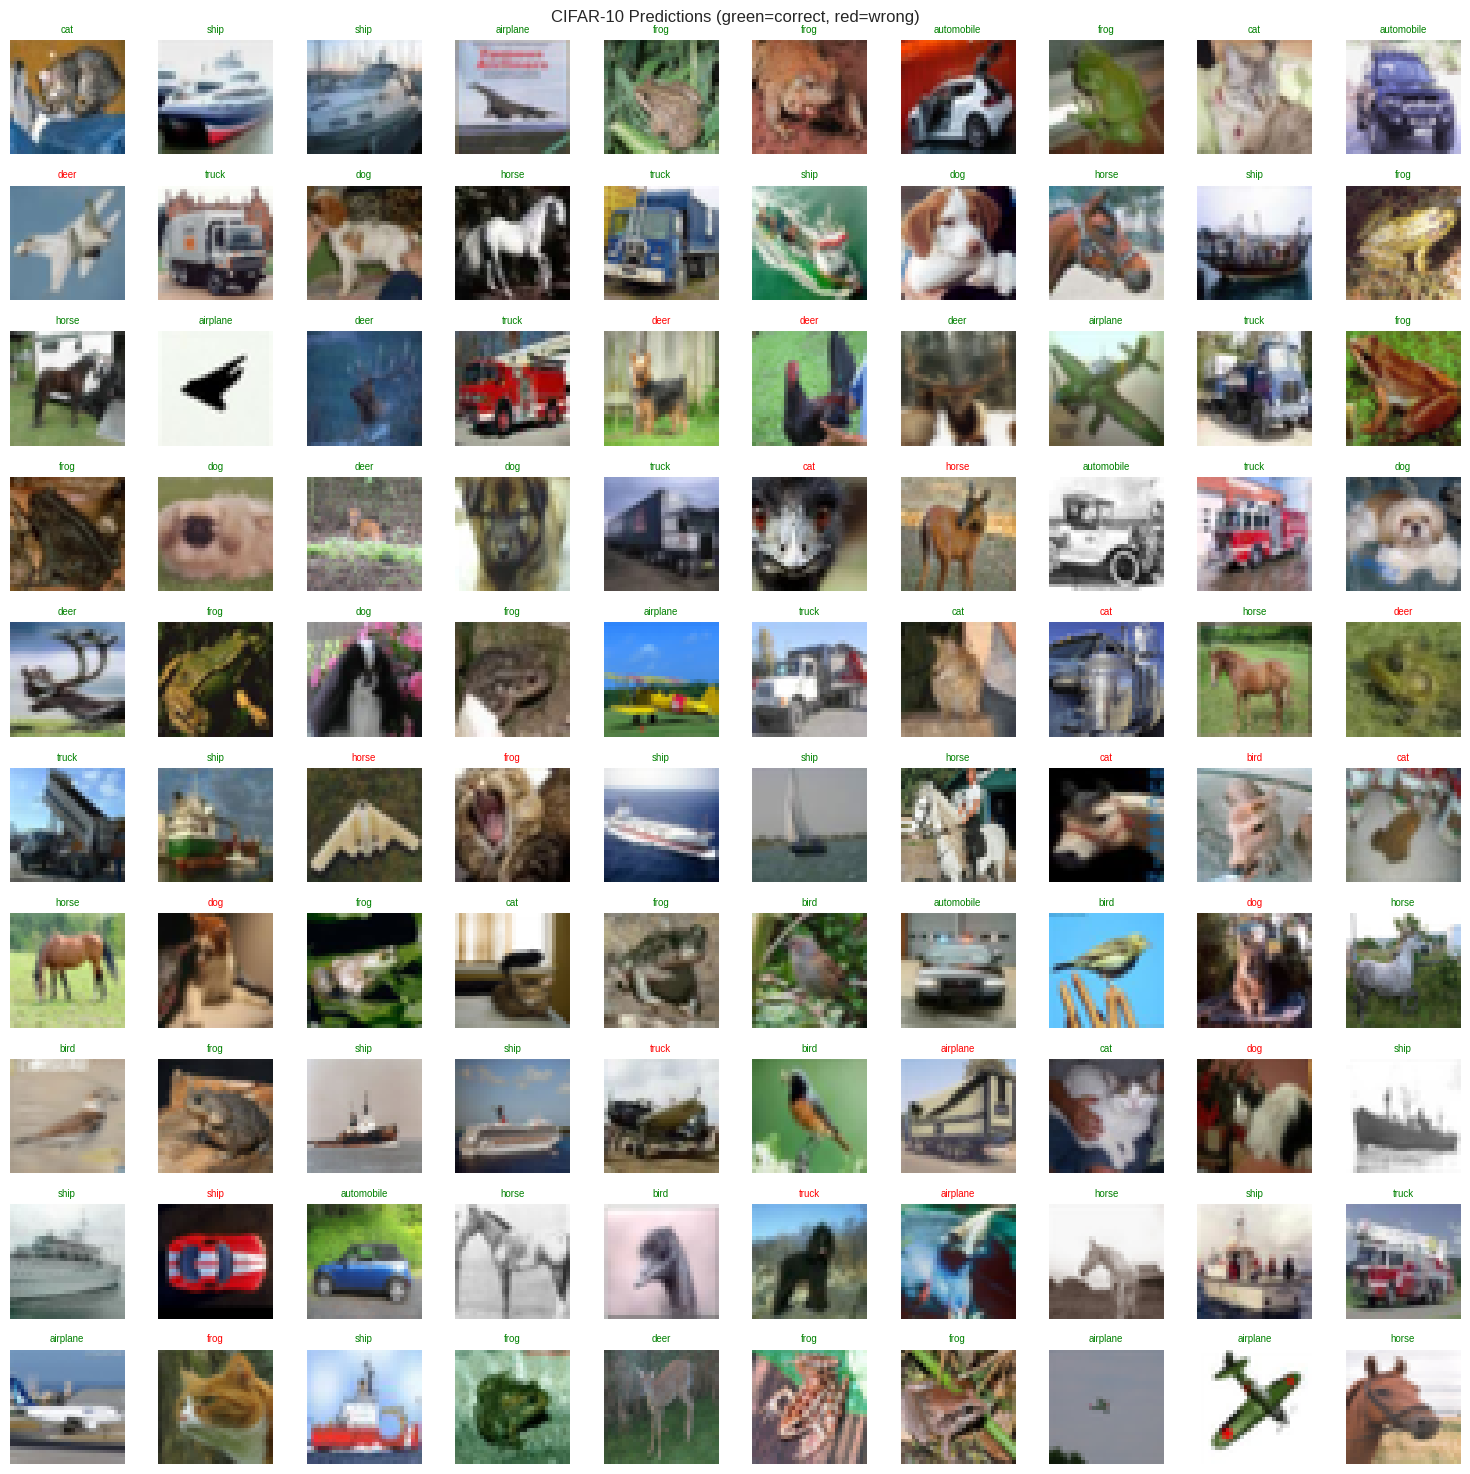

In [9]:
# ── Training curves ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cnn_cifar.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_cnn_cifar.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('CIFAR-10 CNN: Loss', fontsize=13)
axes[0].legend()

axes[1].plot(history_cnn_cifar.history['accuracy'], label='Train Acc', linewidth=2)
axes[1].plot(history_cnn_cifar.history['val_accuracy'], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('CIFAR-10 CNN: Accuracy', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Sample predictions on the test set ────────────────────────────────────────
# Run the model on the first 100 test images and compare with ground truth.
# Green title = correct prediction, red title = wrong prediction.
preds_cifar = np.argmax(cnn_cifar.predict(X_test_cifar[:100], verbose=0), axis=1)
true_cifar  = y_test_cifar[:100, 0]   # remove the extra dim from CIFAR-10 labels

fig, axes = plt.subplots(10, 10, figsize=(15, 15))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_test_cifar[i])
    color = 'green' if preds_cifar[i] == true_cifar[i] else 'red'
    ax.set_title(cifar_classes[preds_cifar[i]], fontsize=7, color=color)
    ax.axis('off')
plt.suptitle('CIFAR-10 Predictions (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.show()

### CNN on Medical Images: Chest X-ray (PneumoniaMNIST)

PneumoniaMNIST consists of 28x28 grayscale chest X-ray images from the dataset published by Guangzhou Women and Children's Medical Center. The task is binary classification: normal vs. pneumonia.

Train: (4708, 28, 28, 1), Val: (524, 28, 28, 1), Test: (624, 28, 28, 1)
Train distribution: Normal=1214, Pneumonia=3494


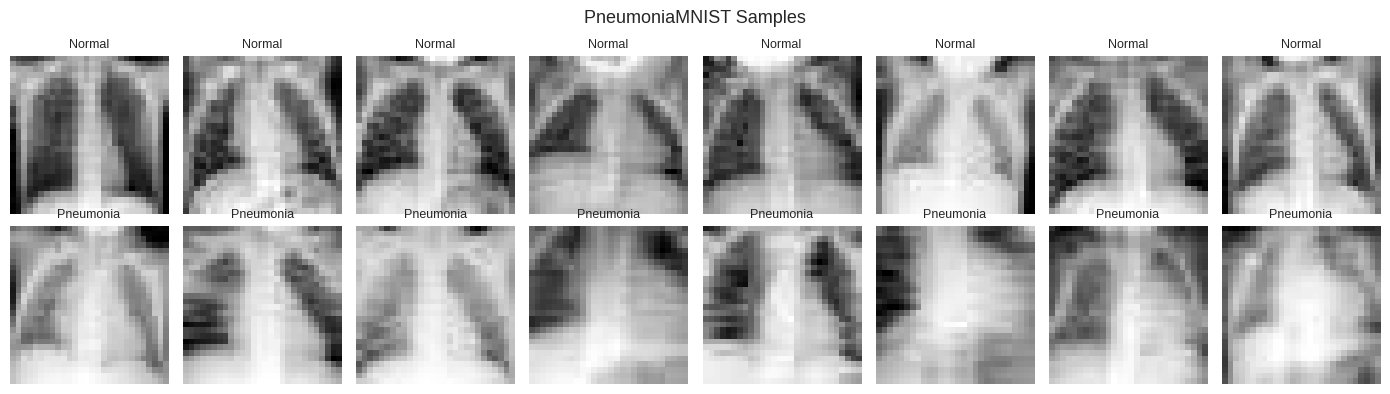

In [10]:
# Download PneumoniaMNIST from MedMNIST (Zenodo).
# tf.keras.utils.get_file caches the file locally after the first download.
url_med = "https://zenodo.org/records/10519652/files/pneumoniamnist.npz"
path_med = tf.keras.utils.get_file("pneumoniamnist.npz", url_med)
med_data = np.load(path_med)

# This dataset already comes with a dedicated validation split (unlike MNIST/CIFAR)
X_train_med = med_data['train_images'].astype('float32') / 255.0
y_train_med  = med_data['train_labels'].ravel()   # .ravel() flattens (N,1) → (N,)
X_val_med    = med_data['val_images'].astype('float32') / 255.0
y_val_med    = med_data['val_labels'].ravel()
X_test_med   = med_data['test_images'].astype('float32') / 255.0
y_test_med   = med_data['test_labels'].ravel()

# Add channel dimension: (N, 28, 28) → (N, 28, 28, 1)  [greyscale = 1 channel]
X_train_med = X_train_med[..., np.newaxis]
X_val_med   = X_val_med[..., np.newaxis]
X_test_med  = X_test_med[..., np.newaxis]

class_names_med = ['Normal', 'Pneumonia']
print(f"Train: {X_train_med.shape}, Val: {X_val_med.shape}, Test: {X_test_med.shape}")
print(f"Train distribution: Normal={np.sum(y_train_med==0)}, Pneumonia={np.sum(y_train_med==1)}")
# Note the class imbalance — pneumonia cases are more common in this dataset,
# which is typical in real-world medical datasets.

# Show 8 examples of each class to visually inspect the data
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for label in range(2):
    idxs = np.where(y_train_med == label)[0][:8]
    for j, idx in enumerate(idxs):
        ax = axes[label, j]
        ax.imshow(X_train_med[idx, :, :, 0], cmap='gray')
        ax.set_title(class_names_med[label], fontsize=9)
        ax.axis('off')
plt.suptitle('PneumoniaMNIST Samples', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# ── Binary CNN for medical image classification ────────────────────────────────
# Key differences from the multi-class CNNs above:
#   • Output neuron: Dense(1, sigmoid) instead of Dense(10, softmax).
#     sigmoid outputs a single probability p(pneumonia); threshold at 0.5 to decide.
#   • Loss: binary_crossentropy (appropriate for two-class problems).
#   • Extra metric: AUC (Area Under the ROC Curve) — especially useful when
#     classes are imbalanced, as it measures discrimination ability independently
#     of the classification threshold.
#   • Dropout(0.4): stronger regularisation because the medical dataset is smaller.
cnn_med = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')   # single output for binary classification
])

cnn_med.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# We pass the explicit validation set instead of using validation_split,
# because the dataset already provides a proper val split.
history_cnn_med = cnn_med.fit(
    X_train_med, y_train_med,
    validation_data=(X_val_med, y_val_med),
    epochs=15,
    batch_size=64,
    verbose=1
)

results_med = cnn_med.evaluate(X_test_med, y_test_med, verbose=0)
print(f"\nTest Accuracy: {results_med[1]:.2%}, Test AUC: {results_med[2]:.4f}")

Epoch 1/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7630 - auc: 0.7801 - loss: 0.4847 - val_accuracy: 0.8531 - val_auc: 0.9558 - val_loss: 0.3137
Epoch 2/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8891 - auc: 0.9494 - loss: 0.2621 - val_accuracy: 0.9256 - val_auc: 0.9759 - val_loss: 0.1932
Epoch 3/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9195 - auc: 0.9638 - loss: 0.2123 - val_accuracy: 0.9447 - val_auc: 0.9818 - val_loss: 0.1646
Epoch 4/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9278 - auc: 0.9725 - loss: 0.1854 - val_accuracy: 0.9485 - val_auc: 0.9847 - val_loss: 0.1486
Epoch 5/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9335 - auc: 0.9741 - loss: 0.1775 - val_accuracy: 0.9599 - val_auc: 0.9866 - val_loss: 0.1360
Epoch 6/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9369 - auc: 0.9773 - loss: 0.1662 - val_accuracy: 0.9523 - val_auc: 0.9888 - val_loss: 0.1468
Epoch 7/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - 

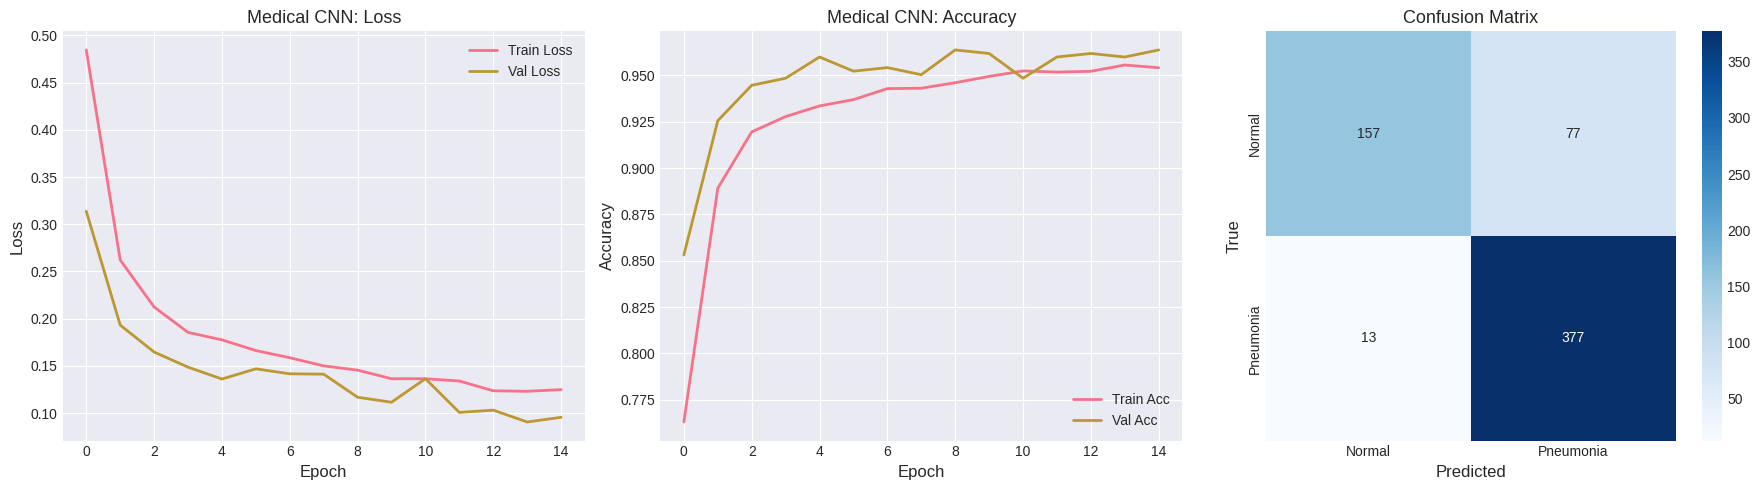

              precision    recall  f1-score   support

      Normal       0.92      0.67      0.78       234
   Pneumonia       0.83      0.97      0.89       390

    accuracy                           0.86       624
   macro avg       0.88      0.82      0.84       624
weighted avg       0.87      0.86      0.85       624



In [12]:
# ── Evaluation: training curves, confusion matrix, classification report ───────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_cnn_med.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_cnn_med.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Medical CNN: Loss', fontsize=13)
axes[0].legend()

axes[1].plot(history_cnn_med.history['accuracy'], label='Train Acc', linewidth=2)
axes[1].plot(history_cnn_med.history['val_accuracy'], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Medical CNN: Accuracy', fontsize=13)
axes[1].legend()

# Threshold the sigmoid output at 0.5 to obtain binary (0/1) predictions
y_pred_med = (cnn_med.predict(X_test_med, verbose=0) > 0.5).astype(int).ravel()
cm_med = confusion_matrix(y_test_med, y_pred_med)
sns.heatmap(cm_med, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=class_names_med, yticklabels=class_names_med, square=True)
axes[2].set_xlabel('Predicted', fontsize=12)
axes[2].set_ylabel('True', fontsize=12)
axes[2].set_title('Confusion Matrix', fontsize=13)

plt.tight_layout()
plt.show()

# classification_report gives precision, recall, and F1-score per class.
# In medical settings, recall (sensitivity) for the positive class (Pneumonia)
# is often more important than raw accuracy.
print(classification_report(y_test_med, y_pred_med, target_names=class_names_med))

---
## 11. Recurrent Neural Networks

An RNN processes a sequence $x^1, x^2, \ldots, x^M$ by maintaining a hidden state $h^i$ updated at each time step:

$$h^i = \tanh(W_h\, h^{i-1} + W_x\, x^i + b_h)$$
$$\hat{y}^i = W_y\, h^i + b_y$$

Weights $W_h, W_x, W_y$ are shared across all time steps. Training proceeds via backpropagation through time (BPTT).

### SimpleRNN on Sine Wave

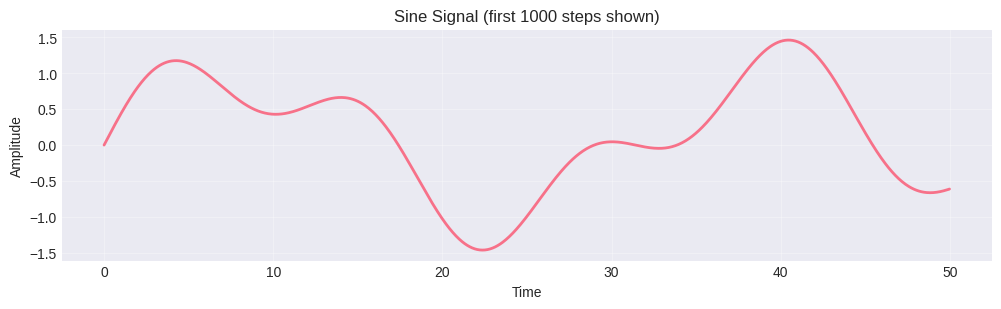

Train: (1560, 50, 1), Test: (390, 50, 1)


In [13]:
# ── Generate a synthetic composite sine signal ─────────────────────────────────
# signal(t) = sin(0.2t) + 0.5·sin(0.5t)
# Two superimposed sinusoids with different frequencies — the network must learn
# the combined periodic pattern from short windows of past values.
t = np.linspace(0, 100, 2000)   # 2000 points uniformly spaced in [0, 100]
signal = np.sin(0.2 * t) + 0.5 * np.sin(0.5 * t)

plt.figure(figsize=(12, 3))
plt.plot(t[:1000], signal[:1000], linewidth=2)
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Sine Signal (first 1000 steps shown)')
plt.grid(True, alpha=0.3)
plt.show()

# ── Sliding-window dataset construction ────────────────────────────────────────
# Each sample is a window of seq_len=50 consecutive values (the input X)
# and the immediately following value (the target y).
# The window slides one step at a time, so consecutive samples overlap heavily.
# This gives 2000 - 50 = 1950 (input, target) pairs in total.
def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])    # window: data[i .. i+seq_len-1]
        y.append(data[i + seq_len])      # target: the next value
    return np.array(X), np.array(y)

seq_len = 50
X_seq, y_seq = make_sequences(signal, seq_len)
X_seq = X_seq[..., np.newaxis]  # RNNs expect shape (samples, timesteps, features)

# Chronological 80/20 split — earlier part of the trajectory trains the model,
# later part tests whether it generalises to unseen future values.
split = int(0.8 * len(X_seq))
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

print(f"Train: {X_train_seq.shape}, Test: {X_test_seq.shape}")

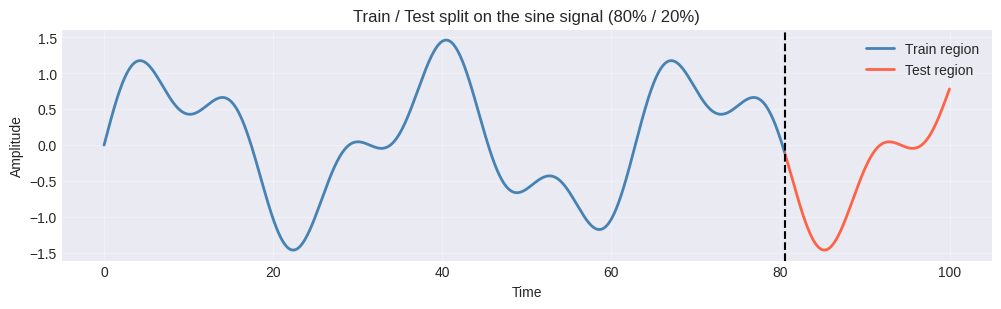

In [14]:
# ── Visualise the train/test split on the original signal ─────────────────────
# split_idx accounts for the seq_len offset: the first test *target* is signal[split + seq_len],
# so the test region on the signal starts there.
split_idx = split + seq_len
plt.figure(figsize=(12, 3))
plt.plot(t[:split_idx], signal[:split_idx], linewidth=2, label='Train region', color='steelblue')
plt.plot(t[split_idx:], signal[split_idx:], linewidth=2, label='Test region', color='tomato')
plt.axvline(t[split_idx], color='k', linestyle='--', linewidth=1.5)
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Train / Test split on the sine signal (80% / 20%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# ── SimpleRNN for one-step-ahead sine wave prediction ─────────────────────────
# SimpleRNN(64): 64 hidden units; at each of the 50 time steps it updates
# its hidden state h^i = tanh(W_h·h^{i-1} + W_x·x^i + b_h).
# Dense(1): maps the final hidden state to a single scalar prediction.
# MSE (mean squared error) is the natural loss for regression.
rnn_sine = keras.Sequential([
    layers.SimpleRNN(64, input_shape=(seq_len, 1)),
    layers.Dense(1)
])

rnn_sine.compile(optimizer='adam', loss='mse')
rnn_sine.fit(X_train_seq, y_train_seq, validation_split=0.1,
             epochs=20, batch_size=64, verbose=1)

Epoch 1/20


/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0360 - val_loss: 6.6794e-04
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.1151e-04 - val_loss: 3.7614e-05
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9597e-04 - val_loss: 9.9223e-06
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0944e-04 - val_loss: 1.4579e-05
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.4166e-05 - val_loss: 1.1500e-05
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.9453e-05 - val_loss: 1.8371e-05
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.7990e-05 - val_loss: 1.9366e-05
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.9981e-05 - val_loss: 1.9025e-05
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3929e-05 - val_loss: 1.4261e-05
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.9143e-05 - val_loss: 6.8168e-06
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.4966e-05 - val_loss: 1.9886e-06
E


Test MSE: 0.000014


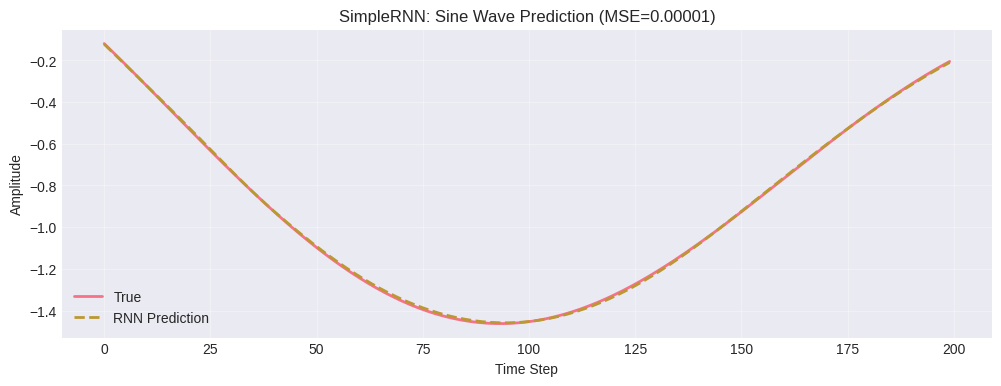

In [16]:
y_pred_rnn = rnn_sine.predict(X_test_seq, verbose=0).ravel()
test_mse_sine = np.mean((y_test_seq - y_pred_rnn) ** 2)
print(f"\nTest MSE: {test_mse_sine:.6f}")

# Plot true vs predicted values for the first 200 test windows
plt.figure(figsize=(12, 4))
plt.plot(y_test_seq[:200], label='True', linewidth=2)
plt.plot(y_pred_rnn[:200], label='RNN Prediction', linewidth=2, linestyle='--')
plt.xlabel('Time Step')
plt.ylabel('Amplitude')
plt.title(f'SimpleRNN: Sine Wave Prediction (MSE={test_mse_sine:.5f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### SimpleRNN on Airline Passengers

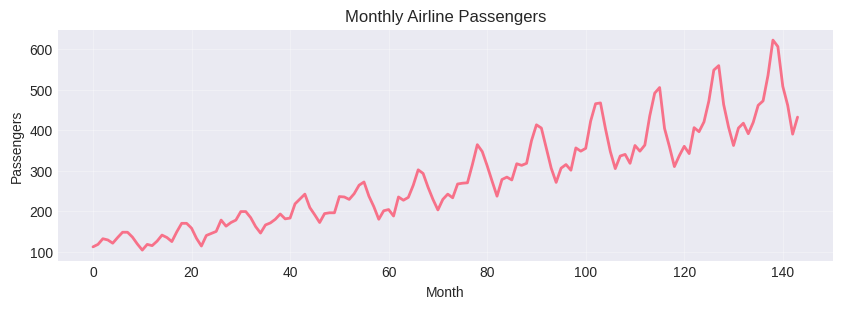

Train: (105, 12, 1), Test: (27, 12, 1)


In [17]:
# ── Airline passengers dataset ────────────────────────────────────────────────
# Monthly totals from 1949–1960 (144 data points).  Strong upward trend and
# yearly seasonality make it a classic time-series benchmark.
flights = sns.load_dataset('flights')
passengers = flights['passengers'].values.astype('float32')

plt.figure(figsize=(10, 3))
plt.plot(passengers, linewidth=2)
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.title('Monthly Airline Passengers')
plt.grid(True, alpha=0.3)
plt.show()

# MinMaxScaler maps values to [0, 1].  This is important because RNNs/LSTMs
# are sensitive to input scale (tanh and sigmoid saturate for large values).
# We fit the scaler on the full series here for simplicity; in a strict
# pipeline you would fit only on the training portion.
scaler = MinMaxScaler()
passengers_scaled = scaler.fit_transform(passengers.reshape(-1, 1)).ravel()

# Window of 12 months → predict month 13.  Chosen to capture yearly seasonality.
seq_len_f = 12
X_flights, y_flights = make_sequences(passengers_scaled, seq_len_f)
X_flights = X_flights[..., np.newaxis]   # (samples, 12, 1)

# Chronological 80/20 split — earlier months train, later months test
split_f = int(0.8 * len(X_flights))
X_train_f, X_test_f = X_flights[:split_f], X_flights[split_f:]
y_train_f, y_test_f = y_flights[:split_f], y_flights[split_f:]

print(f"Train: {X_train_f.shape}, Test: {X_test_f.shape}")

In [18]:
# ── SimpleRNN on airline passengers ───────────────────────────────────────────
# 50 hidden units, trained for 100 epochs with a small batch (16) to match
# the small dataset (only ~115 training windows).
rnn_flights = keras.Sequential([
    layers.SimpleRNN(50, input_shape=(seq_len_f, 1)),
    layers.Dense(1)
])

rnn_flights.compile(optimizer='adam', loss='mse')
rnn_flights.fit(X_train_f, y_train_f, epochs=100, batch_size=16, verbose=0)

y_pred_rnn_f     = rnn_flights.predict(X_test_f, verbose=0).ravel()

/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


SimpleRNN RMSE: 33.93


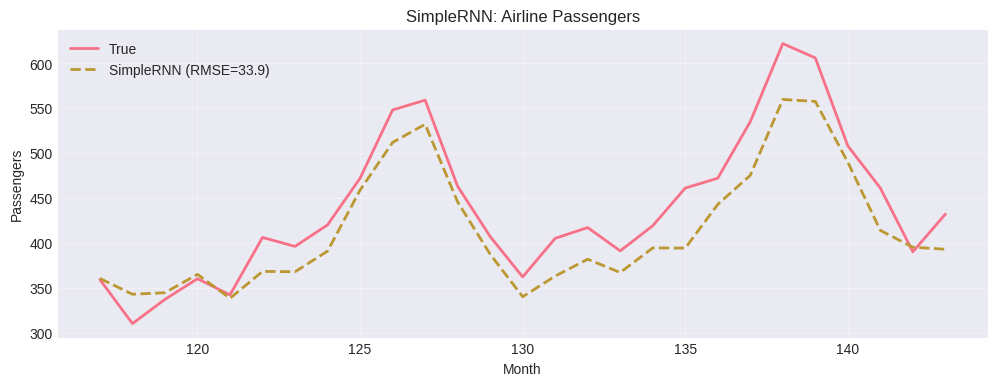

In [19]:
# Inverse-transform to recover the original passenger counts (undo MinMaxScaler)
y_pred_rnn_f_inv = scaler.inverse_transform(y_pred_rnn_f.reshape(-1, 1)).ravel()
y_test_f_inv     = scaler.inverse_transform(y_test_f.reshape(-1, 1)).ravel()

# RMSE in the original passenger units is easier to interpret than scaled MSE
rnn_rmse = np.sqrt(np.mean((y_test_f_inv - y_pred_rnn_f_inv) ** 2))
print(f"SimpleRNN RMSE: {rnn_rmse:.2f}")

# Align predictions with the correct month indices on the horizontal axis
x_axis = range(len(passengers) - len(y_test_f_inv), len(passengers))
plt.figure(figsize=(12, 4))
plt.plot(x_axis, y_test_f_inv, label='True', linewidth=2)
plt.plot(x_axis, y_pred_rnn_f_inv, label=f'SimpleRNN (RMSE={rnn_rmse:.1f})', linewidth=2, linestyle='--')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.title('SimpleRNN: Airline Passengers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 12. Long Short-Term Memory Networks

LSTMs address the vanishing gradient problem with a gating mechanism. A cell state $c^i$ carries long-term information and is updated via:

$$f^i = \sigma(W^f [h^{i-1}, x^i] + b^f) \qquad \text{(forget gate)}$$
$$i^i = \sigma(W^i [h^{i-1}, x^i] + b^i) \qquad \text{(input gate)}$$
$$\tilde{c}^i = \tanh(W^c [h^{i-1}, x^i] + b^c) \qquad \text{(candidate cell state)}$$
$$c^i = f^i \odot c^{i-1} + i^i \odot \tilde{c}^i$$
$$o^i = \sigma(W^o [h^{i-1}, x^i] + b^o) \qquad \text{(output gate)}$$
$$h^i = o^i \odot \tanh(c^i)$$


### LSTM on Airline Passengers

In [20]:
# ── LSTM on airline passengers ────────────────────────────────────────────────
# Same architecture and training setup as the SimpleRNN above — the only change
# is replacing SimpleRNN with LSTM.  This lets us directly compare how much the
# gating mechanism helps on a dataset with long-range dependencies (yearly trend).
lstm_flights = keras.Sequential([
    layers.LSTM(50, input_shape=(seq_len_f, 1)),
    layers.Dense(1)
])

lstm_flights.compile(optimizer='adam', loss='mse')
lstm_flights.fit(X_train_f, y_train_f, epochs=100, batch_size=16, verbose=0)

/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


SimpleRNN RMSE: 33.93
LSTM RMSE:      53.88


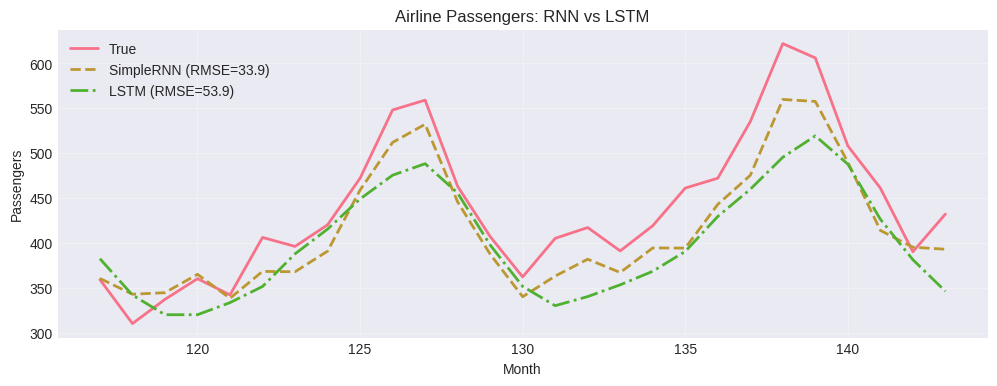

In [21]:
y_pred_lstm_f     = lstm_flights.predict(X_test_f, verbose=0).ravel()
y_pred_lstm_f_inv = scaler.inverse_transform(y_pred_lstm_f.reshape(-1, 1)).ravel()

lstm_rmse = np.sqrt(np.mean((y_test_f_inv - y_pred_lstm_f_inv) ** 2))
print(f"SimpleRNN RMSE: {rnn_rmse:.2f}")
print(f"LSTM RMSE:      {lstm_rmse:.2f}")

# ── Side-by-side comparison ────────────────────────────────────────────────────
# Lower RMSE indicates better forecasting.  LSTM often wins here because the
# airline series has a 12-month seasonal period — beyond the "memory horizon"
# of a SimpleRNN trained with standard backpropagation through time.
plt.figure(figsize=(12, 4))
plt.plot(x_axis, y_test_f_inv, label='True', linewidth=2)
plt.plot(x_axis, y_pred_rnn_f_inv,  label=f'SimpleRNN (RMSE={rnn_rmse:.1f})',  linewidth=2, linestyle='--')
plt.plot(x_axis, y_pred_lstm_f_inv, label=f'LSTM (RMSE={lstm_rmse:.1f})', linewidth=2, linestyle='-.')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.title('Airline Passengers: RNN vs LSTM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### LSTM on ECG Classification

ECG time series from the PTB Diagnostic ECG Database, each sample containing 140 time steps. The task is binary: normal heartbeat vs. abnormal.

ECG dataset: (4998, 140)
Classes: [2079 2919] (0=abnormal, 1=normal)


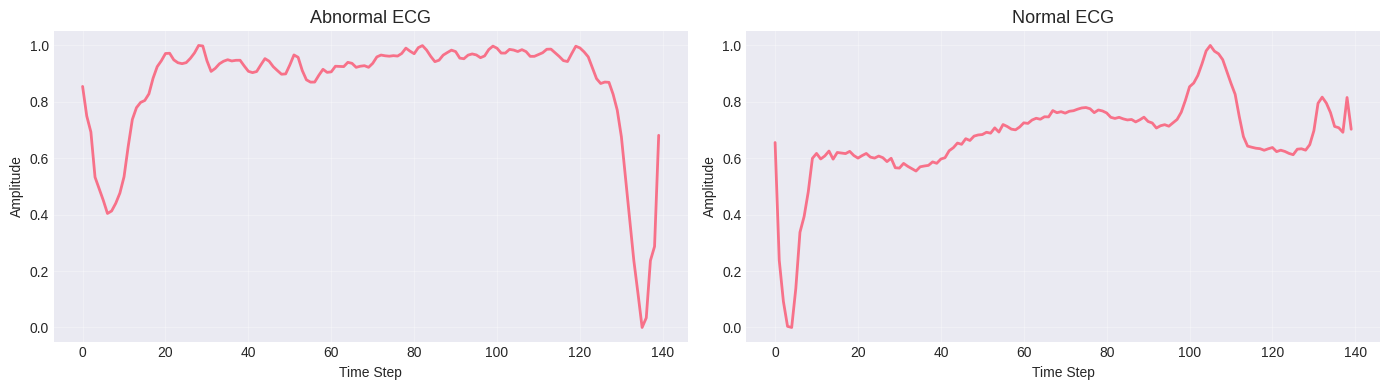

In [22]:
# ── Load the ECG dataset ───────────────────────────────────────────────────────
# Each row contains 140 voltage measurements (one heartbeat) + a label column.
# Label: 1 = normal heartbeat, 0 = abnormal (various arrhythmias).
ecg_path = tf.keras.utils.get_file(
    "ecg.csv",
    "https://storage.googleapis.com/download.tensorflow.org/data/ecg.csv"
)
ecg_data = np.loadtxt(ecg_path, delimiter=',')
X_ecg = ecg_data[:, :-1].astype('float32')   # columns 0–139: voltage time series
y_ecg = ecg_data[:, -1].astype(int)           # last column:   class label

print(f"ECG dataset: {X_ecg.shape}")
print(f"Classes: {np.bincount(y_ecg)} (0=abnormal, 1=normal)")

# Per-sample normalisation: scale each individual heartbeat to [0, 1].
# This removes amplitude differences between patients/leads while preserving shape.
# We add 1e-8 to avoid division by zero for flat signals.
X_ecg_min = X_ecg.min(axis=1, keepdims=True)
X_ecg_max = X_ecg.max(axis=1, keepdims=True)
X_ecg = (X_ecg - X_ecg_min) / (X_ecg_max - X_ecg_min + 1e-8)

# Chronological 80/20 split (no shuffling — preserves patient ordering)
split_ecg    = int(0.8 * len(X_ecg))
X_train_ecg  = X_ecg[:split_ecg, :, np.newaxis]   # add feature dim → (N, 140, 1)
y_train_ecg  = y_ecg[:split_ecg]
X_test_ecg   = X_ecg[split_ecg:, :, np.newaxis]
y_test_ecg   = y_ecg[split_ecg:]

# Visualise one example of each class so we can see what the model is learning
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for cls, ax in zip([0, 1], axes):
    idx = np.where(y_ecg[:split_ecg] == cls)[0][0]
    ax.plot(X_ecg[idx], linewidth=2)
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Amplitude')
    ax.set_title('Abnormal ECG' if cls == 0 else 'Normal ECG', fontsize=13)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# ── Stacked LSTM classifier for ECG ───────────────────────────────────────────
# Why stacked (two LSTM layers)?
#   • The first LSTM reads the full 140-step sequence and outputs a hidden state
#     at every step (return_sequences=True), building a higher-level representation.
#   • The second LSTM condenses that sequence into a single fixed-size vector.
#   • This two-level hierarchy can capture both local waveform features and
#     global heartbeat morphology.
lstm_ecg = keras.Sequential([
    layers.LSTM(64, input_shape=(140, 1), return_sequences=True),  # outputs (batch, 140, 64)
    layers.LSTM(32),                                                 # outputs (batch, 32)
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')   # binary output: P(normal)
])

lstm_ecg.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

lstm_ecg.summary()

# EarlyStopping: halt training if val_loss does not improve for 10 consecutive
# epochs, and restore the weights from the best epoch.  Prevents overfitting
# on the relatively small ECG dataset.
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history_ecg = lstm_ecg.fit(
    X_train_ecg, y_train_ecg,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

results_ecg = lstm_ecg.evaluate(X_test_ecg, y_test_ecg, verbose=0)
print(f"\nTest Accuracy: {results_ecg[1]:.2%}, Test AUC: {results_ecg[2]:.4f}")


/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 140, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8685 - auc: 0.8605 - loss: 0.3301 - val_accuracy: 0.9425 - val_auc: 0.0000e+00 - val_loss: 0.2011
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9844 - auc: 0.9922 - loss: 0.0587 - val_accuracy: 0.9375 - val_auc: 0.0000e+00 - val_loss: 0.2034
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9855 - auc: 0.9924 - loss: 0.0577 - val_accuracy: 0.9300 - val_auc: 0.0000e+00 - val_loss: 0.1953
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9855 - auc: 0.9947 - loss: 0.0502 - val_accuracy: 0.9625 - val_auc: 0.0000e+00 - val_loss: 0.1358
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9914 - auc: 0.9979 - loss: 0.0308 - val_accuracy: 0.9425 - val_auc: 0.0000e+00 - val_loss: 0.1681
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9922 - auc: 0.9967 - loss: 0.0311 - val_accuracy: 0.9425 - val_auc: 0.0000e+00 - val_loss: 0.1655
Epoch 7/50

In [24]:
# EarlyStopping: halt training if val_loss does not improve for 10 consecutive
# epochs, and restore the weights from the best epoch.  Prevents overfitting
# on the relatively small ECG dataset.
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history_ecg = lstm_ecg.fit(
    X_train_ecg, y_train_ecg,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

results_ecg = lstm_ecg.evaluate(X_test_ecg, y_test_ecg, verbose=0)
print(f"\nTest Accuracy: {results_ecg[1]:.2%}, Test AUC: {results_ecg[2]:.4f}")

Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9900 - auc: 0.9974 - loss: 0.0320 - val_accuracy: 0.9500 - val_auc: 0.0000e+00 - val_loss: 0.1662
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9908 - auc: 0.9977 - loss: 0.0273 - val_accuracy: 0.9550 - val_auc: 0.0000e+00 - val_loss: 0.1521
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9928 - auc: 0.9978 - loss: 0.0250 - val_accuracy: 0.9575 - val_auc: 0.0000e+00 - val_loss: 0.1517
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9928 - auc: 0.9971 - loss: 0.0271 - val_accuracy: 0.9525 - val_auc: 0.0000e+00 - val_loss: 0.1464
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9911 - auc: 0.9976 - loss: 0.0296 - val_accuracy: 0.9400 - val_auc: 0.0000e+00 - val_loss: 0.2007
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9917 - auc: 0.9974 - loss: 0.0279 - val_accuracy: 0.9575 - val_auc: 0.0000e+00 - val_loss: 0.1447
Epoch 7/50

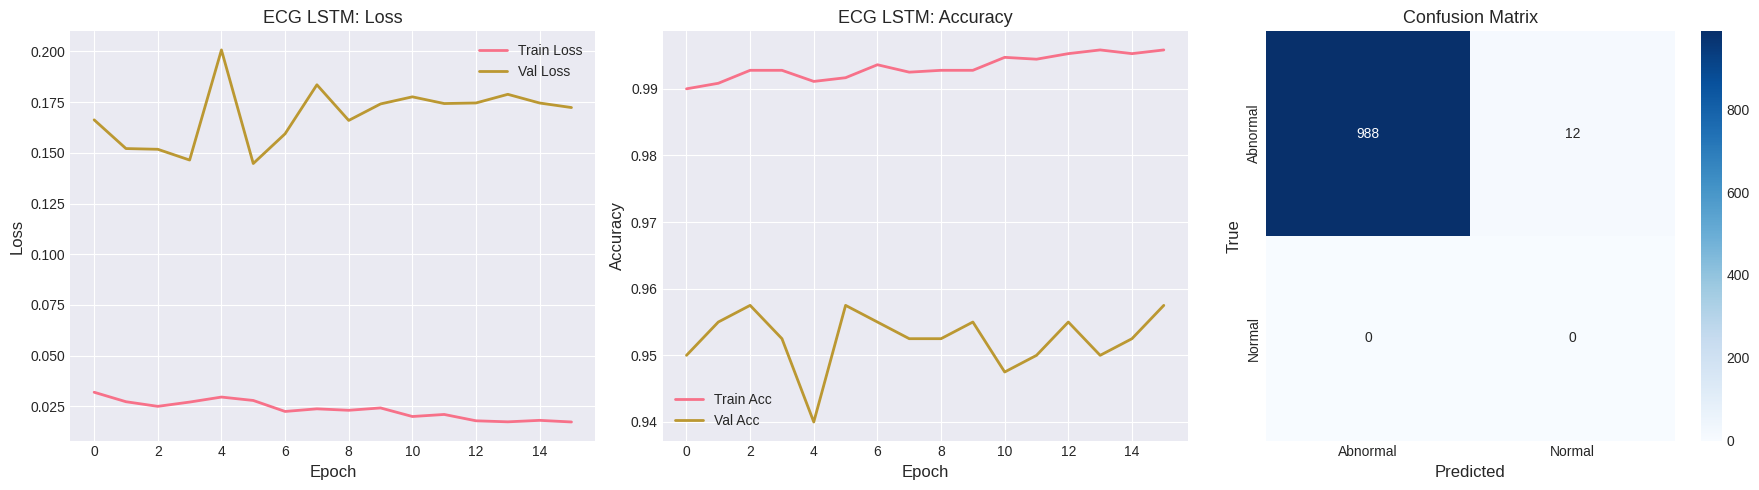

              precision    recall  f1-score   support

    Abnormal       1.00      0.99      0.99      1000
      Normal       0.00      0.00      0.00         0

    accuracy                           0.99      1000
   macro avg       0.50      0.49      0.50      1000
weighted avg       1.00      0.99      0.99      1000



/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 i

In [25]:
# ── Evaluation: training curves, confusion matrix, classification report ───────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_ecg.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_ecg.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('ECG LSTM: Loss', fontsize=13)
axes[0].legend()

axes[1].plot(history_ecg.history['accuracy'], label='Train Acc', linewidth=2)
axes[1].plot(history_ecg.history['val_accuracy'], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('ECG LSTM: Accuracy', fontsize=13)
axes[1].legend()

# Threshold sigmoid output at 0.5 to obtain hard binary labels
y_pred_ecg = (lstm_ecg.predict(X_test_ecg, verbose=0) > 0.5).astype(int).ravel()
cm_ecg = confusion_matrix(y_test_ecg, y_pred_ecg)
# Confusion matrix layout (rows=true, cols=predicted):
#   TN  FP
#   FN  TP
# FN (bottom-left): abnormal heartbeats classified as normal — the most dangerous errors.
sns.heatmap(cm_ecg, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Abnormal', 'Normal'],
            yticklabels=['Abnormal', 'Normal'], square=True)
axes[2].set_xlabel('Predicted', fontsize=12)
axes[2].set_ylabel('True', fontsize=12)
axes[2].set_title('Confusion Matrix', fontsize=13)

plt.tight_layout()
plt.show()

# Full per-class precision / recall / F1 breakdown
print(classification_report(y_test_ecg, y_pred_ecg, target_names=['Abnormal', 'Normal']))